In [188]:
import pandas as pd
import re
import nltk
import numpy as np
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from nltk.stem import PorterStemmer


from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


### Get all unique values for spell.csv the "type coulmn"

In [189]:
import pandas as pd
import re
from nltk.tokenize import word_tokenize



df = pd.read_csv("Spells.csv")
print(df.head())
print(df.columns.tolist())

   Spell ID       Incantation                        Spell Name  \
0         1             Accio                   Summoning Charm   
1         2         Aguamenti                Water-Making Spell   
2         3  Alarte Ascendare  Launch an object up into the air   
3         4         Alohomora                   Unlocking Charm   
4         5     Arania Exumai            Spider repelling spell   

                  Effect     Light  
0      Summons an object       NaN  
1         Conjures water  Icy blue  
2  Rockets target upward       Red  
3         Unlocks target      Blue  
4         Repels spiders      Blue  
['Spell ID', 'Incantation', 'Spell Name', 'Effect', 'Light']


# Show all unique spell names

In [190]:
# Show all unique spell names
unique_spell_names = df["Spell Name"].dropna().unique()

print(unique_spell_names)
print(f"\nTotal unique spell names: {len(unique_spell_names)}")

['Summoning Charm' 'Water-Making Spell' 'Launch an object up into the air'
 'Unlocking Charm' 'Spider repelling spell' 'Slowing Charm'
 'Killing Curse' 'Exploding Charm' 'Brackium Emendo' 'Cistem Aperio'
 'Locking Spell' 'Blasting Curse' 'Cruciatus Curse' 'Severing Charm'
 'Dissendium' 'Engorgement Charm' 'Episkey' 'Patronus Charm'
 'Disarming Charm' 'Expulso Curse' 'General Counter-Spell'
 'Human Presence Revealing Spell' 'Freezing Charm' 'Impediment Jinx'
 'Imperius Curse' 'Incarcerous Spell' 'Fire-Making Spell' 'Levicorpus'
 'Locomotion Charm' 'Leg-Locker Curse' 'Wand-Lighting Charm'
 'Lumos Maxima' 'Lumos Solem Spell' 'Muffliato Charm'
 'Wand-Extinguishing Charm' 'Memory Charm' 'Oculus Reparo' 'Oppugno Jinx'
 'Peskipiksi Pesternomi' 'Full Body-Bind Curse' 'Piertotum Locomotor'
 'Portus' 'Reverse Spell' 'Shield Charm' 'Protego Maxima'
 'Protego totalum' 'Shrinking Charm' 'Revulsion Jinx' 'Mending Charm'
 'Repello Inimicum' 'Muggle-Repelling Charm' 'Revelio Charm'
 'Tickling Charm' '

In [191]:
print(df.isnull().sum())

Spell ID        0
Incantation     0
Spell Name      0
Effect          0
Light          21
dtype: int64


In [192]:
# Combine text fields
# Include spell type if present so LDA can use explicit class signals where available.
type_col_candidates = [column for column in df.columns if str(column).strip().lower() == "type"]
type_series = df[type_col_candidates[0]].fillna("") if type_col_candidates else ""

df["text"] = (
    df["Spell Name"].fillna("") + " "
    + df["Effect"].fillna("") + " "
    + type_series
)

# Lowercase
df["text"] = df["text"].str.lower()

# Remove punctuation
df["text"] = df["text"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", x)
)
import nltk

# Tokenization
df["tokens"] = df["text"].apply(word_tokenize)

# Standard English stopwords
stop_words = set(stopwords.words("english"))

# Harry Potter / dataset-specific stopwords
# Keep generic class words out so topics depend on distinctive terms.
custom_stopwords = {
 
}

# Combine both sets
all_stopwords = stop_words.union(custom_stopwords)

# Remove stopwords
df["tokens"] = df["tokens"].apply(
    lambda words: [w for w in words if w not in all_stopwords]
)

stemmer = PorterStemmer()
lemmer = WordNetLemmatizer()

df["tokens"] = df["tokens"].apply(
    #lambda words: [stemmer.stem(w) for w in words]
    lambda words: [lemmer.lemmatize(w) for w in words]
)

# View results
print(df[["Spell Name", "tokens"]].head(20))

                          Spell Name  \
0                    Summoning Charm   
1                 Water-Making Spell   
2   Launch an object up into the air   
3                    Unlocking Charm   
4             Spider repelling spell   
5                      Slowing Charm   
6                      Killing Curse   
7                    Exploding Charm   
8                    Brackium Emendo   
9                      Cistem Aperio   
10                     Locking Spell   
11                    Blasting Curse   
12                   Cruciatus Curse   
13                    Severing Charm   
14                        Dissendium   
15                 Engorgement Charm   
16                           Episkey   
17                    Patronus Charm   
18                   Disarming Charm   
19                     Expulso Curse   

                                             tokens  
0               [summoning, charm, summons, object]  
1             [watermaking, spell, conjures, water]

### Making a dictionary

In [193]:
dictionary = Dictionary(df["tokens"])
dictionary.filter_extremes(
    no_below=1,
    no_above=0.7
)
corpus = [dictionary.doc2bow(text) for text in df["tokens"]]

### Small model

In [194]:
# Guided LDA priors (still LDA): stronger bias for offensive/dark vs defensive/healing terms.
defensive_seed_words = ["heal", "heals", "healing", "episkey", "patronus", "shield", "protect", "protego", "counter", "mend", "defensive"]
offensive_seed_words = ["kill", "killing", "death", "cruciatus", "imperius", "imperio", "avada", "dark", "torture", "unforgivable", "pain", "victim", "curse"]

eta = np.full((3, len(dictionary)), 0.001, dtype=float)
for word in offensive_seed_words:
    word_id = dictionary.token2id.get(word)
    if word_id is not None:
        eta[0, word_id] = 4.0
for word in defensive_seed_words:
    word_id = dictionary.token2id.get(word)
    if word_id is not None:
        eta[1, word_id] = 4.0

alpha = np.array([0.1, 0.1, 0.1])
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=3,
    random_state=42,
    passes=40,
    alpha=alpha,
    eta=eta
)

In [195]:
for idx, topic in lda_model.print_topics():
    print(f"Topic {idx}: {topic}")

Topic 0: 0.069*"spell" + 0.055*"charm" + 0.052*"curse" + 0.034*"killing" + 0.034*"death" + 0.034*"cruciatus" + 0.034*"pain" + 0.034*"victim" + 0.034*"imperius" + 0.021*"conjures"
Topic 1: 0.048*"charm" + 0.048*"protego" + 0.040*"shield" + 0.040*"mend" + 0.032*"object" + 0.032*"target" + 0.032*"patronus" + 0.032*"episkey" + 0.032*"heals" + 0.027*"curse"
Topic 2: 0.097*"charm" + 0.055*"target" + 0.042*"spell" + 0.042*"jinx" + 0.028*"snake" + 0.028*"object" + 0.028*"memory" + 0.014*"water" + 0.014*"force" + 0.014*"wand"


In [196]:
# Store dominant topic for each spell
dominant_topics = []

# Store full topic probabilities
topic_distributions = []

for bow in corpus:

    # Get topic probabilities
    topic_probs = lda_model.get_document_topics(bow)

    # Save full probability distribution
    topic_distributions.append(topic_probs)

    # Get dominant topic
    dominant_topic = max(topic_probs, key=lambda x: x[1])

    dominant_topics.append(dominant_topic[0])

# Add dominant topic column to dataframe
df["Dominant Topic"] = dominant_topics
print(df[["Spell Name", "Dominant Topic"]].head(20))

                          Spell Name  Dominant Topic
0                    Summoning Charm               0
1                 Water-Making Spell               0
2   Launch an object up into the air               1
3                    Unlocking Charm               2
4             Spider repelling spell               0
5                      Slowing Charm               1
6                      Killing Curse               0
7                    Exploding Charm               1
8                    Brackium Emendo               1
9                      Cistem Aperio               0
10                     Locking Spell               2
11                    Blasting Curse               1
12                   Cruciatus Curse               0
13                    Severing Charm               0
14                        Dissendium               1
15                 Engorgement Charm               1
16                           Episkey               2
17                    Patronus Charm          

In [197]:
# LDA-only topic labeling with unique category assignment across all topics.
def topic_profile(topic_id: int) -> dict:
    topic_rows = df[df["Dominant Topic"] == topic_id]
    if topic_rows.empty:
        return {
            "topic_id": topic_id,
            "offensive": 0,
            "defensive": 0,
        }

    type_col_candidates = [column for column in df.columns if str(column).strip().lower() == "type"]
    type_col = type_col_candidates[0] if type_col_candidates else None

    topic_text = (
        topic_rows["Spell Name"].fillna("").str.lower()
        + " "
        + topic_rows["Effect"].fillna("").str.lower()
    )
    if type_col:
        topic_text = topic_text + " " + topic_rows[type_col].fillna("").str.lower()

    offensive_markers = ["imperius", "imperio", "cruciatus", "avada", "killing", "kill", "death", "torture", "pain", "dark", "curse", "Curse"]
    defensive_markers = ["heal", "healing", "episkey", "patronus", "shield", "protect", "protego", "counter", "mend", "disarm"]

    offensive_score = sum(topic_text.str.contains(marker, regex=False).sum() for marker in offensive_markers)
    defensive_score = sum(topic_text.str.contains(marker, regex=False).sum() for marker in defensive_markers)
  

    return {
        "topic_id": topic_id,
        "offensive": int(offensive_score),
        "defensive": int(defensive_score),
    }

profiles = [topic_profile(topic_id) for topic_id in range(lda_model.num_topics)]
profiles_df = pd.DataFrame(profiles)

# Enforce unique top-level categories: exactly one Offensive and one Defensive topic.
offensive_topic = profiles_df.sort_values(["offensive", "defensive"], ascending=[False, True]).iloc[0]["topic_id"]
defensive_topic = remaining.sort_values(["defensive", "offensive"], ascending=[False, True]).iloc[0]["topic_id"]
    

topic_labels = {
    int(offensive_topic): f"LDA Topic {int(offensive_topic)}: Offensive/Dark",
    int(defensive_topic): f"LDA Topic {int(defensive_topic)}: Defensive/Healing",
}

df["Topic Label"] = df["Dominant Topic"].map(topic_labels)

In [198]:
print(df[["Spell Name", "Dominant Topic", "Topic Label"]].head(15))


                          Spell Name  Dominant Topic  \
0                    Summoning Charm               0   
1                 Water-Making Spell               0   
2   Launch an object up into the air               1   
3                    Unlocking Charm               2   
4             Spider repelling spell               0   
5                      Slowing Charm               1   
6                      Killing Curse               0   
7                    Exploding Charm               1   
8                    Brackium Emendo               1   
9                      Cistem Aperio               0   
10                     Locking Spell               2   
11                    Blasting Curse               1   
12                   Cruciatus Curse               0   
13                    Severing Charm               0   
14                        Dissendium               1   

                       Topic Label  
0      LDA Topic 0: Offensive/Dark  
1      LDA Topic 0: Offensive

In [199]:
# show me all the spells with dominant topic
print(df[df["Dominant Topic"] == 3][["Spell Name", "Dominant Topic", "Topic Label"]])


Empty DataFrame
Columns: [Spell Name, Dominant Topic, Topic Label]
Index: []


In [200]:
type_col_candidates = [column for column in df.columns if str(column).strip().lower() == "type"]
view_columns = ["Spell Name", "Effect", "Dominant Topic", "Topic Label"]
if type_col_candidates:
    view_columns.insert(1, type_col_candidates[0])

print(
    df[df["Spell Name"].isin(["Episkey", "Cruciatus Curse", "Killing Curse", "Imperius Curse"])][view_columns]
)

         Spell Name                         Effect  Dominant Topic  \
6     Killing Curse            Instantaneous death               0   
12  Cruciatus Curse              Excruciating pain               0   
16          Episkey           Heals minor injuries               2   
24   Imperius Curse  Total control over the victim               0   

                       Topic Label  
6      LDA Topic 0: Offensive/Dark  
12     LDA Topic 0: Offensive/Dark  
16  LDA Topic 2: Defensive/Healing  
24     LDA Topic 0: Offensive/Dark  


# Creating spell topic matrix

In [201]:
topic_matrix = []

for bow in corpus:

    # Get full topic probability distribution
    topic_probs = lda_model.get_document_topics(
        bow,
        minimum_probability=0
    )

    # Convert to dictionary
    row = {
        f"Topic_{topic_id}": prob
        for topic_id, prob in topic_probs
    }

    topic_matrix.append(row)

# Create dataframe
spell_topic_matrix = pd.DataFrame(topic_matrix)

spell_topic_matrix.insert(0, "Spell Name", df["Spell Name"].values)

spell_topic_matrix.insert(1, "Incantation", df["Incantation"].values)

spell_topic_matrix.insert(2, "Dominant Topic", df["Dominant Topic"].values)

spell_topic_matrix.insert(3, "Topic Label", df["Topic Label"].values)

# Preview
print(spell_topic_matrix.head(10))

                         Spell Name       Incantation  Dominant Topic  \
0                   Summoning Charm             Accio               0   
1                Water-Making Spell         Aguamenti               0   
2  Launch an object up into the air  Alarte Ascendare               1   
3                   Unlocking Charm         Alohomora               2   
4            Spider repelling spell     Arania Exumai               0   
5                     Slowing Charm  Arresto Momentum               1   
6                     Killing Curse     Avada Kedavra               0   
7                   Exploding Charm          Bombarda               1   
8                   Brackium Emendo   Brackium Emendo               1   
9                     Cistem Aperio     Cistem Aperio               0   

                      Topic Label   Topic_0   Topic_1   Topic_2  
0     LDA Topic 0: Offensive/Dark  0.953476  0.023261  0.023263  
1     LDA Topic 0: Offensive/Dark  0.953481  0.023257  0.023262 

### Saving to csv

In [202]:
# CSV for easy integration
spell_topic_matrix.to_csv(
    "spell_topic_matrix.csv",
    index=False
)

# Pickle for Python loading
spell_topic_matrix.to_pickle(
    "spell_topic_matrix.pkl"
)

# Save trained LDA model
lda_model.save("lda_spell_model.gensim")

# Save dictionary
dictionary.save("spell_dictionary.gensim")

print("Files saved successfully.")

Files saved successfully.


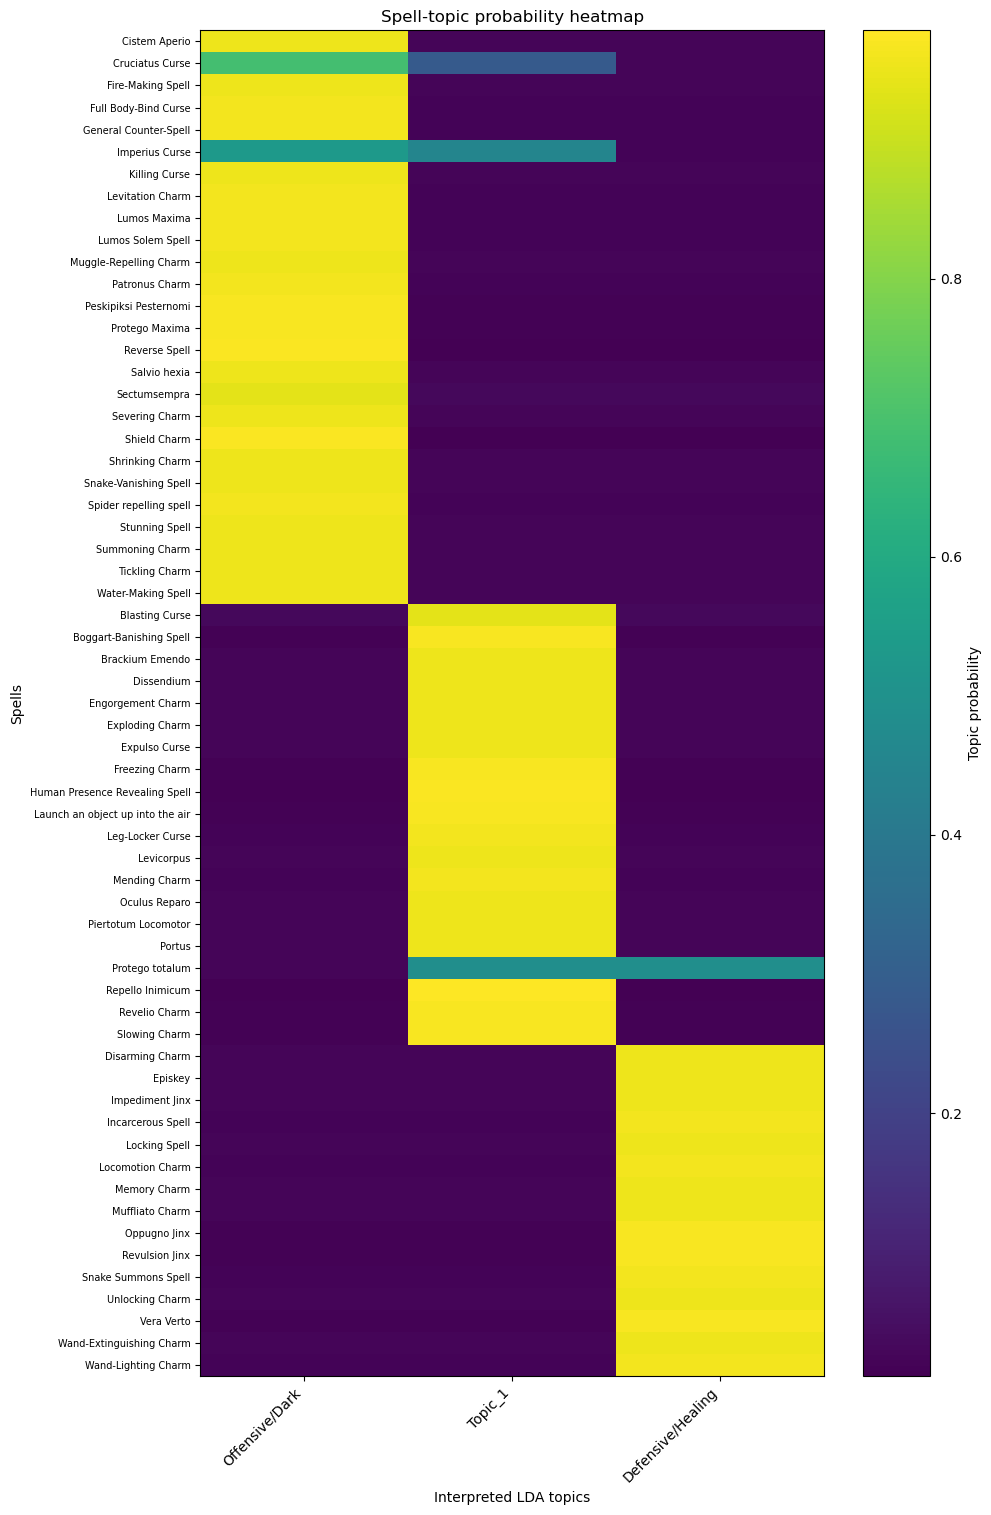

In [203]:
import matplotlib.pyplot as plt

# Copy matrix
heatmap_df = spell_topic_matrix.copy()

# Select topic columns
topic_cols = [col for col in heatmap_df.columns if col.startswith("Topic_")]

# Sort spells by dominant topic for readability
heatmap_df = heatmap_df.sort_values(
    by=["Dominant Topic", "Spell Name"]
)

# Use spell names as row labels
heatmap_data = heatmap_df.set_index("Spell Name")[topic_cols]

# Rename topic columns using interpreted labels
topic_name_map = {
    f"Topic_{topic_id}": label.replace(f"LDA Topic {topic_id}: ", "")
    for topic_id, label in topic_labels.items()
}

heatmap_data = heatmap_data.rename(columns=topic_name_map)

# Plot all spells
plt.figure(figsize=(10, max(8, len(heatmap_data) * 0.25)))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Topic probability")

plt.xticks(
    ticks=range(len(heatmap_data.columns)),
    labels=heatmap_data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=range(len(heatmap_data.index)),
    labels=heatmap_data.index,
    fontsize=7
)

plt.title("Spell-topic probability heatmap")
plt.xlabel("Interpreted LDA topics")
plt.ylabel("Spells")

plt.tight_layout()
plt.show()

The heatmap visualizes the topic distribution of each spell. Each row represents a spell, and each column represents one interpreted LDA topic. Brighter cells indicate a higher probability that the spell belongs to that topic. This illustrates that the model represents spells probabilistically: most spells have one dominant topic, while some spells contain elements of several magical themes. 1233
